## Sanity checks

In [1]:
import numpy as np
import scipy.sparse as sps

%matplotlib inline

import analysis as am
import encoding as E

In [2]:
def dense(M):
    return np.asarray(M.todense()) if sps.issparse(M) else np.asarray(M)

for nb in (1, 2, 3):
    n, nl = 4 * nb, 2 * nb
    U = E.get_encoder_isometry(nb)
    proj = lambda op, U=U: dense(U.conj().T @ E.as_csr(op) @ U)
    Zb = lambda k, nl=nl: E.logical_Z(k, nl).full()
    Xb = lambda k, nl=nl: E.logical_X(k, nl).full()

    assert np.allclose(dense(U.conj().T @ U), np.eye(2 ** nl))              # isometry

    for i in range(nb):                                             # Table II
        a, b, q = 2 * i, 2 * i + 1, 4 * i
        Z_, X_ = lambda k, n=n: E.Z(k, n), lambda k, n=n: E.X(k, n)
        assert np.allclose(proj(Z_(q)   * Z_(q+1)),  Zb(a))
        assert np.allclose(proj(Z_(q)   * Z_(q+2)),  Zb(b))
        assert np.allclose(proj(Z_(q+1) * Z_(q+2)),  Zb(a) @ Zb(b))
        assert np.allclose(proj(X_(q)   * X_(q+2)), -Xb(a))
        assert np.allclose(proj(X_(q)   * X_(q+1)),  Xb(b))
        assert np.allclose(proj(X_(q+1) * X_(q+2)), -Xb(a) @ Xb(b))

    # S_enc is in the kernel of Hpen
    assert np.abs(dense(E.as_csr(E.build_Hpen(nb)) @ U)).max() < 1e-12

    # Each penalty term projects to a logical Pauli and has no leakage outside the code space
    P = E.get_encoder_projector(U)
    I = sps.identity(U.shape[0], format="csr")
    for kind, p, g, Pa in E.penalty_terms(nb):
        M, i, sign = proj(Pa), p // 2, (+1 if p % 2 == 0 else -1)
        want = Xb(2 * i + 1) if kind == "x" else Zb(2 * i)
        assert np.allclose(M, sign * want)                          # closed form
        assert np.abs(dense((I - P) @ E.as_csr(Pa) @ U)).max() < 1e-12   # no leakage

    print(f"nb={nb}: Table II, isometry, kernel, closed form and no-leakage all verified")

nb=1: Table II, isometry, kernel, closed form and no-leakage all verified
nb=2: Table II, isometry, kernel, closed form and no-leakage all verified
nb=3: Table II, isometry, kernel, closed form and no-leakage all verified


## $n_b = 2$: what was simulated

| axis | values |
|---|---|
| $\lambda$ | $2^0, 2^1, \dots 2^{16}$ |
| $\delta$ | $0,\ 10^{-7},\ 10^{-6},\ 10^{-5},\ 10^{-4},\ 10^{-3}$ |
| seed | $0,1, \dots, 49$ (50 realisations of noise + miscalibration + initial state) |

To regenerate the data files in `data/` from scratch:

```bash
python Hpen_miscal/simulate.py --nb 2 --noise 0.1 --t 1.0 \
  --lamb 1,2,4,8,16,32,64,128,256,512,1024,2048,4096,8192,16384,32768,65536 \
  --miscal 0,1e-7,1e-6,1e-5,1e-4,1e-3 --seeds 0-49 --outdir Hpen_miscal/data
```

## $n_b = 2$: results

In [3]:
res = am.report(nb=2, noise=0.1, t=1.0)

Penalty miscalibration sweep: nb = 2, noise = 0.1, t = 1.0, 50 seeds
  lamb  1 .. 65536 (17 values)
  delta [0.0, 1e-07, 1e-06, 1e-05, 0.0001, 0.001]

1. delta = 0 baseline (fitted over lamb >= 32)
   A = lamb * eps = 0.4197   (per-lamb spread 0.380-0.458)
   eps / leakage = 1.0117  (the infidelity is almost entirely leakage)

2. Global fit of the EXCESS  eps(l,d) - eps(l,0) = B d^2 l^2
   (69 points, paired per seed, weighted by the SEM of the difference)
   B = 7.918
   No linear term: <eps> is even in delta (u -> -u symmetry).  Seed-averaged
   slope excess/delta at delta = 1e-07, which is sampling noise only:
     lamb =  1   -0.1670 +- 0.0819   (-2.0 SEM)
     lamb =  2   -0.1558 +- 0.1006   (-1.5 SEM)
     lamb =  4   -0.2276 +- 0.1379   (-1.6 SEM)
     lamb =  8   -0.2354 +- 0.1647   (-1.4 SEM)

3. B against the analytic form B = kappa * (20/3) * nb
   B_analytic = kappa * (20/3) * nb = kappa * 13.333
   => kappa = 0.594   (expected O(1), <~ 1)

4. lambda_opt by parabolic fit of

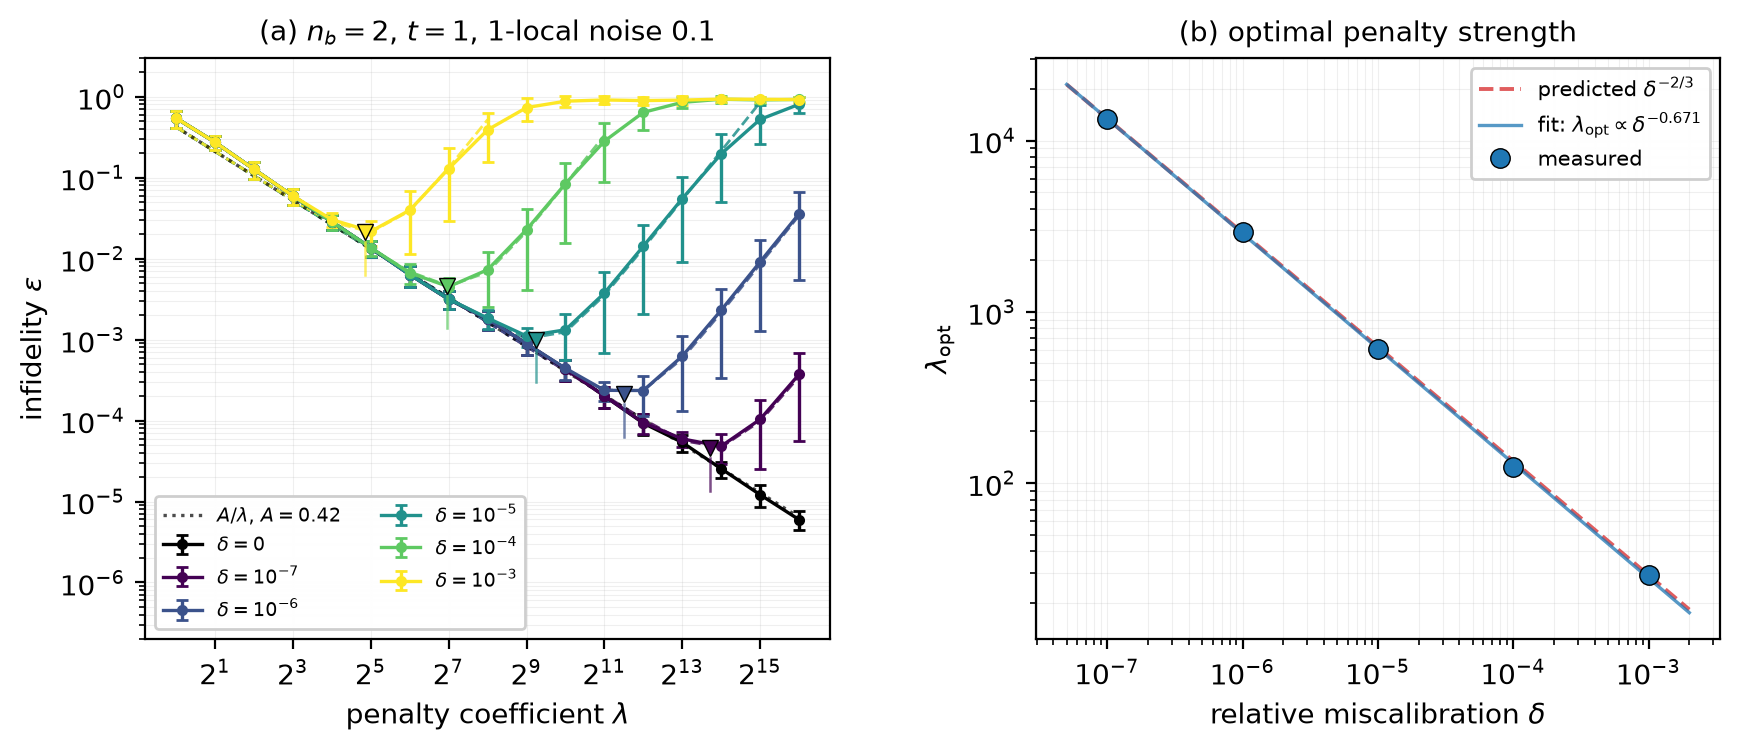

In [4]:
pdf, png = am.make_figure(res, "fig_miscal_2blocks.pdf", noise=0.1)
from IPython.display import Image, display

display(Image(filename=png))

## $n_b = 3$: what was simulated

| axis | values |
|---|---|
| $\lambda$ | $2^0, 2^1, \dots 2^{14}$ |
| $\delta$ | $0,\ 10^{-6},\ 10^{-5},\ 10^{-4},\ 10^{-3}$ |
| seed | $0,1, \dots, 49$ (50 realisations of noise + miscalibration + initial state) |

The physical Hilbert space is $2^{12} = 4096$-dimensional, so `simulate.py` propagates with `scipy.sparse.linalg.expm_multiply` (its default for $n_b \ge 3$).
Its cost grows linearly with $\lambda$ (about $7\,\mathrm{ms} \times \lambda$ per point on one core), so the grid stops at $\lambda = 2^{14}$.
$\delta = 10^{-7}$ is left out because its optimum ($\lambda_{\rm opt} \approx 1.3 \times 10^4$ at $n_b = 2$) would sit at the edge of that grid; the remaining optima all lie well inside it.

To regenerate the data files serially (~15 h):

```bash
python Hpen_miscal/simulate.py --nb 3 --noise 0.1 --t 1.0 \
  --lamb 1,2,4,8,16,32,64,128,256,512,1024,2048,4096,8192,16384 \
  --miscal 0,1e-6,1e-5,1e-4,1e-3 --seeds 0-49 --outdir Hpen_miscal/data
```

Or in parallel (~75 min on 16 cores, which is how the data here were produced).
Each (seed, $\delta$) pair runs as an independent process, and concatenating the per-seed files in seed order gives output byte-identical to the serial run:

```bash
L=1,2,4,8,16,32,64,128,256,512,1024,2048,4096,8192,16384
for s in $(seq 0 49); do for d in 0 1e-6 1e-5 1e-4 1e-3; do echo $s $d; done; done |
  OPENBLAS_NUM_THREADS=1 xargs -P 16 -L 1 sh -c \
    'python Hpen_miscal/simulate.py --nb 3 --lamb '$L' --miscal $1 --seeds $0 --outdir parts/s$0_d$1'
for d in 0 1e-6 1e-5 1e-4 1e-3; do
  f=$(basename parts/s0_d$d/*.txt)
  for s in $(seq 0 49); do cat parts/s${s}_d$d/$f; done > Hpen_miscal/data/$f
done
```

## $n_b = 3$: results

In [5]:
res3 = am.report(nb=3, noise=0.1, t=1.0)

Penalty miscalibration sweep: nb = 3, noise = 0.1, t = 1.0, 50 seeds
  lamb  1 .. 16384 (15 values)
  delta [0.0, 1e-06, 1e-05, 0.0001, 0.001]

1. delta = 0 baseline (fitted over lamb >= 32)
   A = lamb * eps = 0.8460   (per-lamb spread 0.780-0.907)
   eps / leakage = 1.0147  (the infidelity is almost entirely leakage)

2. Global fit of the EXCESS  eps(l,d) - eps(l,0) = B d^2 l^2
   (48 points, paired per seed, weighted by the SEM of the difference)
   B = 13.648
   No linear term: <eps> is even in delta (u -> -u symmetry).  Seed-averaged
   slope excess/delta at delta = 1e-06, which is sampling noise only:
     lamb =  1   -0.0215 +- 0.0373   (-0.6 SEM)
     lamb =  2   -0.0347 +- 0.0844   (-0.4 SEM)
     lamb =  4   -0.0845 +- 0.1232   (-0.7 SEM)
     lamb =  8   -0.0960 +- 0.1798   (-0.5 SEM)

3. B against the analytic form B = kappa * (20/3) * nb
   B_analytic = kappa * (20/3) * nb = kappa * 20.000
   => kappa = 0.682   (expected O(1), <~ 1)

4. lambda_opt by parabolic fit of log e

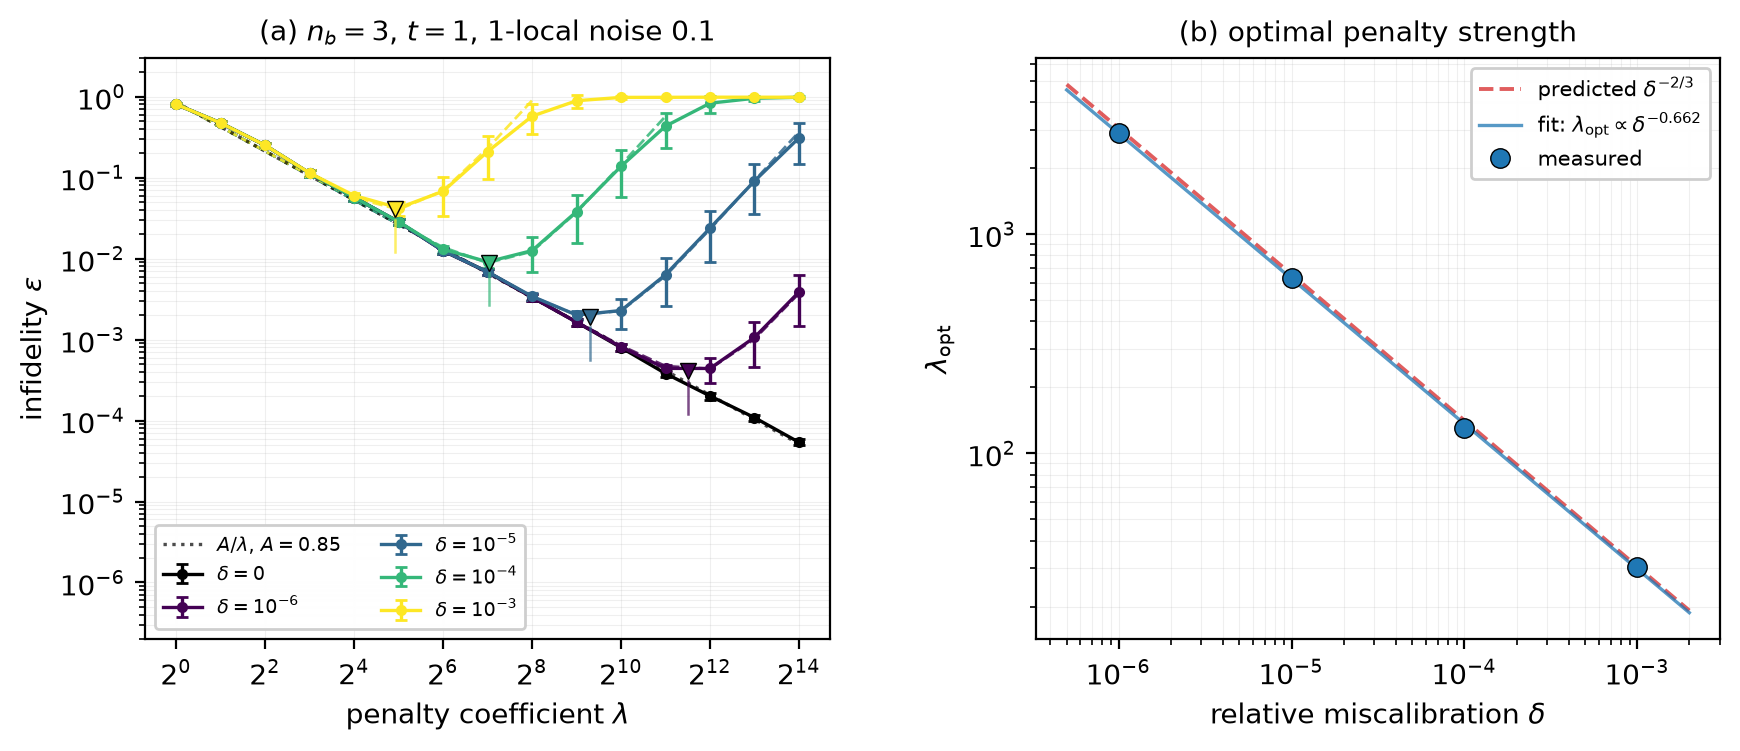

In [6]:
pdf3, png3 = am.make_figure(res3, "fig_miscal_3blocks.pdf", noise=0.1)
display(Image(filename=png3))

## $n_b = 2$ vs $n_b = 3$

In [7]:
# p is refitted over the delta values both runs share, so the two exponents are like for like.
common = [d for d in res3["deltas"] if d > 0 and d in res["deltas"]]


def lopt(r):
    return dict(zip([d for d in r["deltas"] if d > 0], r["lo_raw"]))


def eps_min(r, d):
    return am.agg(r["G"], "infidelity", d, r["lambs"], r["seeds"])[0].min()


p = [am.fit_exponent(common, [lopt(r)[d] for d in common])[0] for r in (res, res3)]
print(f"{'':>20s} {'nb=2':>10s} {'nb=3':>10s}")
for key in ("A", "B", "kappa", "K"):
    print(f"{key:>20s} {res[key]:>10.4g} {res3[key]:>10.4g}")
print(f"{'p (common delta)':>20s} {p[0]:>10.4f} {p[1]:>10.4f}   (predicted 2/3)")
for d in common:
    print(f"{f'lamb_opt({d:.0e})':>20s} {lopt(res)[d]:>10.1f} {lopt(res3)[d]:>10.1f}")
for d in common:
    print(f"{f'eps_min({d:.0e})':>20s} {eps_min(res, d):>10.2e} {eps_min(res3, d):>10.2e}")

                           nb=2       nb=3
                   A     0.4197      0.846
                   B      7.918      13.65
               kappa     0.5939     0.6824
                   K      8.007      13.67
    p (common delta)     0.6698     0.6624   (predicted 2/3)
     lamb_opt(1e-06)     2906.8     2899.3
     lamb_opt(1e-05)      606.0      632.5
     lamb_opt(1e-04)      123.4      130.4
     lamb_opt(1e-03)       28.9       30.4
      eps_min(1e-06)   2.35e-04   4.40e-04
      eps_min(1e-05)   1.11e-03   2.01e-03
      eps_min(1e-04)   4.50e-03   9.12e-03
      eps_min(1e-03)   2.17e-02   4.22e-02
